In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2025-01-01
Revised on 2026-04-03

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to real-world data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Decision Tree Classification — Credit Dataset (ISLR Ch. 8)
===========================================================

Description:
    Demonstrates classification decision tree using the Credit dataset
    from the ISLR/ISLP library. Predicts whether a credit card holder
    is a Student (Yes/No) based on financial and demographic predictors.

    Covers:
      - Exploratory data analysis (EDA)
      - Train/test split
      - Decision tree fit (sklearn.tree.DecisionTreeClassifier)
      - Tree visualization (plot_tree)
      - Cost-complexity pruning path (mirrors R printcp + plotcp)
      - Predictions on test set
      - Confusion matrix and classification report
      - ROC curve with AUC
      - PredictionMetrics custom class

    R equivalent: tree_rpart_classification_ISLR_Credit.Rmd
    R libraries:  rpart, rpart.plot, pROC, caret, ISLR
    Python libs:  ISLP, numpy, pandas, matplotlib, seaborn, sklearn

    Note: The original R Rmd header mentioned 'Random Forest' but the
    actual model is rpart (decision tree). This notebook uses the
    correct title: Decision Tree Classification.

Dataset:
    Credit {ISLR/ISLP} — simulated credit card dataset
    400 observations, 12 variables
    Response variable: Student (Yes=1, No=0)
    Predictors used: Income, Limit, Rating, Gender, Age, Balance

Revision History:
    2025-01-01  Original R development (Harvard STAT 109, 2023)
                - R script: tree_rpart_classification_ISLR_Credit.Rmd

    2026-04-03  Converted to Python / Jupyter Notebook
                - rpart() → sklearn.tree.DecisionTreeClassifier
                - rpart.plot() → sklearn.tree.plot_tree
                - printcp/plotcp → cost_complexity_pruning_path
                - pROC::multiclass.roc → sklearn.metrics.roc_curve
                - caret::confusionMatrix → sklearn.metrics.classification_report
                - PredictionMetrics class carried from notebooks #2 and #3
                - Harvard color palette preserved as hex constants
"""

"\nCreated on 2025-01-01\nRevised on 2026-04-03\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to real-world data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nDecision Tree Classification — Credit Dataset (ISLR Ch. 8)\n===========================================================\n\nDescription:\n    Demonstrates classification decision tree using the Credit dataset\n    from the ISLR/ISLP library. Predicts whether a credit card holder\n    is a Student (Yes/No) based on financial and demographic predictors.\n\n    Covers:\n      - Exploratory data analysis (EDA)\n      - Train/test split\n      - Decision tree fit (sklearn.tree.DecisionTreeClassifier)\n      - Tree visualization (plot_tree)\n      - Cost-complexity pruning path (mirrors R printcp + plotcp)\n      - Predictions on test set\n      - Confusion matrix and classification report\n      -

# Decision Tree Classification — Credit Dataset (ISLR Ch. 8)

## Overview

This notebook demonstrates **classification decision trees** using the
**Credit dataset** from the ISLR/ISLP library (ISLR Chapter 8).

The goal is to predict whether a credit card holder is a **Student** (Yes/No)
from financial and demographic predictors:
`Income`, `Limit`, `Rating`, `Gender`, `Age`, `Balance`.

Covers:
- Exploratory Data Analysis
- Decision tree fit, visualization, and pruning path
- Confusion matrix, custom metrics, and ROC/AUC

**Note on original R file:** The Rmd header mentioned *Random Forest* but the
actual model code uses `rpart` (single decision tree). This notebook uses
the correct title.

**R equivalent:** `tree_rpart_classification_ISLR_Credit.Rmd`

## Imports

In [2]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Decision tree — mirrors R: rpart, rpart.plot
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Model evaluation — mirrors R: caret, pROC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, ConfusionMatrixDisplay)

# ISLP — official dataset companion to ISL with Python
from ISLP import load_data

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')

# -----------------------------------------------------------------------
# Harvard color palette — mirrors R setup chunk
# -----------------------------------------------------------------------
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'
SAFFRON   = '#D16103'
INDIGO    = '#293352'
SHADE     = '#BAC5C6'

print('Imports complete.')

Imports complete.


## PredictionMetrics Class

Carried from notebooks #2 and #3 (univariate and multivariate classification).
Mirrors R functions `prediction.metrics()` and `print.the.metrics()` from
Harvard's Elements of Statistical Learning class (2021).

> **Portfolio note:** This class is a candidate for a shared `utils.py` module
> once all classification notebooks are complete.

In [3]:
class PredictionMetrics:
    """
    Binary classification prediction metrics.

    Mirrors R functions prediction.metrics() and print.the.metrics()
    from Harvard Elements of Statistical Learning class (2021).
    Original R code by Dr. Sivachenko and Dr. Farutin; expanded by Oscar Trevizo.

    Parameters
    ----------
    truth : array-like of int (0 or 1)
    predicted : array-like of int (0 or 1)
    """

    def __init__(self, truth, predicted):
        truth     = np.array(truth)
        predicted = np.array(predicted)
        if len(truth) != len(predicted):
            raise ValueError('truth and predicted must be the same length!')
        mask      = ~(np.isnan(truth.astype(float)) | np.isnan(predicted.astype(float)))
        truth     = truth[mask]
        predicted = predicted[mask]
        if not np.all(np.isin(truth, [0, 1])) or not np.all(np.isin(predicted, [0, 1])):
            raise ValueError('Only zeroes and ones are allowed!')
        self.TP  = int(np.sum((truth == 1) & (predicted == 1)))
        self.TN  = int(np.sum((truth == 0) & (predicted == 0)))
        self.FP  = int(np.sum((truth == 0) & (predicted == 1)))
        self.FN  = int(np.sum((truth == 1) & (predicted == 0)))
        self.P   = self.TP + self.FN
        self.N   = self.FP + self.TN
        self.OBS = len(truth)
        self.ACC = np.sum(truth == predicted) / len(truth)
        self.TPR = self.TP / self.P                    if self.P  > 0 else np.nan
        self.TNR = self.TN / self.N                    if self.N  > 0 else np.nan
        self.PPV = self.TP / (self.TP + self.FP)       if (self.TP + self.FP) > 0 else np.nan
        self.NPV = self.TN / (self.TN + self.FN)       if (self.TN + self.FN) > 0 else np.nan
        self.FDR = self.FP / (self.TP + self.FP)       if (self.TP + self.FP) > 0 else np.nan
        self.FPR = self.FP / self.N                    if self.N  > 0 else np.nan

    def print_metrics(self):
        """Print all metrics — mirrors R: print.the.metrics(metrics)"""
        print(f' OBS = {self.OBS:6d}   ..................number of observations')
        print(f' ACC = {self.ACC:8.4f} ..................Accuracy')
        print(f' TPR = {self.TPR:8.4f} ..................True Positive Rate (Sensitivity)')
        print(f' TNR = {self.TNR:8.4f} ..................True Negative Rate (Specificity)')
        print(f' PPV = {self.PPV:8.4f} ..................Positive Predictive Value (Precision)')
        print(f' NPV = {self.NPV:8.4f} ..................Negative Predictive Value')
        print(f' FDR = {self.FDR:8.4f} ..................False Discovery Rate')
        print(f' FPR = {self.FPR:8.4f} ..................False Positive Rate')
        print(f' TP  = {self.TP:6d}   ..................True Positives')
        print(f' TN  = {self.TN:6d}   ..................True Negatives')
        print(f' FP  = {self.FP:6d}   ..................False Positives')
        print(f' FN  = {self.FN:6d}   ..................False Negatives')
        print(f' P   = {self.P:6d}   ..................Positives (truth)')
        print(f' N   = {self.N:6d}   ..................Negatives (truth)')

    def to_dict(self):
        return dict(OBS=self.OBS, ACC=self.ACC, TPR=self.TPR, TNR=self.TNR,
                    PPV=self.PPV, NPV=self.NPV, FDR=self.FDR, FPR=self.FPR,
                    TP=self.TP, TN=self.TN, FP=self.FP, FN=self.FN,
                    P=self.P, N=self.N)


def plot_roc(fpr, tpr, roc_auc, title='ROC Curve', color=ROYALBLUE):
    """
    Plot ROC curve with AUC.
    Mirrors R: pROC::plot.roc() with print.auc=TRUE, auc.polygon=TRUE.
    """
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'AUC = {roc_auc * 100:.2f}%')
    ax.fill_between(fpr, tpr, alpha=0.15, color='lightblue')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.grid(True, linestyle='--', linewidth=0.5, color='lightgrey')
    ax.set_xlabel('False Positive Rate (1 - Specificity)')
    ax.set_ylabel('True Positive Rate (Sensitivity)')
    ax.set_title(title)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


print('PredictionMetrics class and plot_roc() helper defined.')

PredictionMetrics class and plot_roc() helper defined.


---

## Dataset: Credit {ISLR/ISLP}

The **Credit** dataset is a simulated dataset containing 400 observations
on credit card holders. It includes financial variables (Income, Limit, Rating,
Balance) and demographic variables (Age, Gender, Student, Married, Ethnicity).

**Response variable:** `Student` (Yes=1, No=0) — binary classification target

**Predictors used:**
- `Income` — annual income (thousands of dollars)
- `Limit` — credit limit
- `Rating` — credit rating
- `Gender` — categorical (Male/Female)
- `Age` — age in years
- `Balance` — average credit card balance

## EDA

Mirrors R: `str(Credit); head(Credit); summary(Credit)`

In [4]:
# Load Credit dataset — mirrors R: data(Credit, package='ISLR')
Credit = load_data('Credit')

# Structure — mirrors R: str(Credit)
print(f'Shape: {Credit.shape}')   # 400 observations, 12 variables
print()
print('dtypes:')
print(Credit.dtypes)
print()

Shape: (400, 12)

dtypes:
ID              int64
Income        float64
Limit           int64
Rating          int64
Cards           int64
Age             int64
Education       int64
Gender       category
Student      category
Married      category
Ethnicity    category
Balance         int64
dtype: object



In [5]:
# Head — mirrors R: head(Credit)
Credit.head()

,ID,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


In [6]:
# Summary statistics — mirrors R: summary(Credit)
Credit.describe(include='all').round(2)

,ID,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400,400,400,400,400.00
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Female,No,Yes,Caucasian,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207,360,245,199,NaN
mean,200.50,45.22,4735.60,354.94,2.96,55.67,13.45,NaN,NaN,NaN,NaN,520.02
std,115.61,35.24,2308.20,154.72,1.37,17.25,3.13,NaN,NaN,NaN,NaN,459.76
min,1.00,10.35,855.00,93.00,1.00,23.00,5.00,NaN,NaN,NaN,NaN,0.00
25%,100.75,21.01,3088.00,247.25,2.00,41.75,11.00,NaN,NaN,NaN,NaN,68.75
50%,200.50,33.12,4622.50,344.00,3.00,56.00,14.00,NaN,NaN,NaN,NaN,459.50
75%,300.25,57.47,5872.75,437.25,4.00,70.00,16.00,NaN,NaN,NaN,NaN,863.00


In [7]:
# Class balance for the response variable
print('Response variable Student — class balance:')
print(Credit['Student'].value_counts())
print(f'\nClass proportions:')
print(Credit['Student'].value_counts(normalize=True).round(4))

Response variable Student — class balance:
Student
No     360
Yes     40
Name: count, dtype: int64

Class proportions:
Student
No     0.9
Yes    0.1
Name: proportion, dtype: float64


### EDA Plots

Visualize key predictor distributions by Student status.

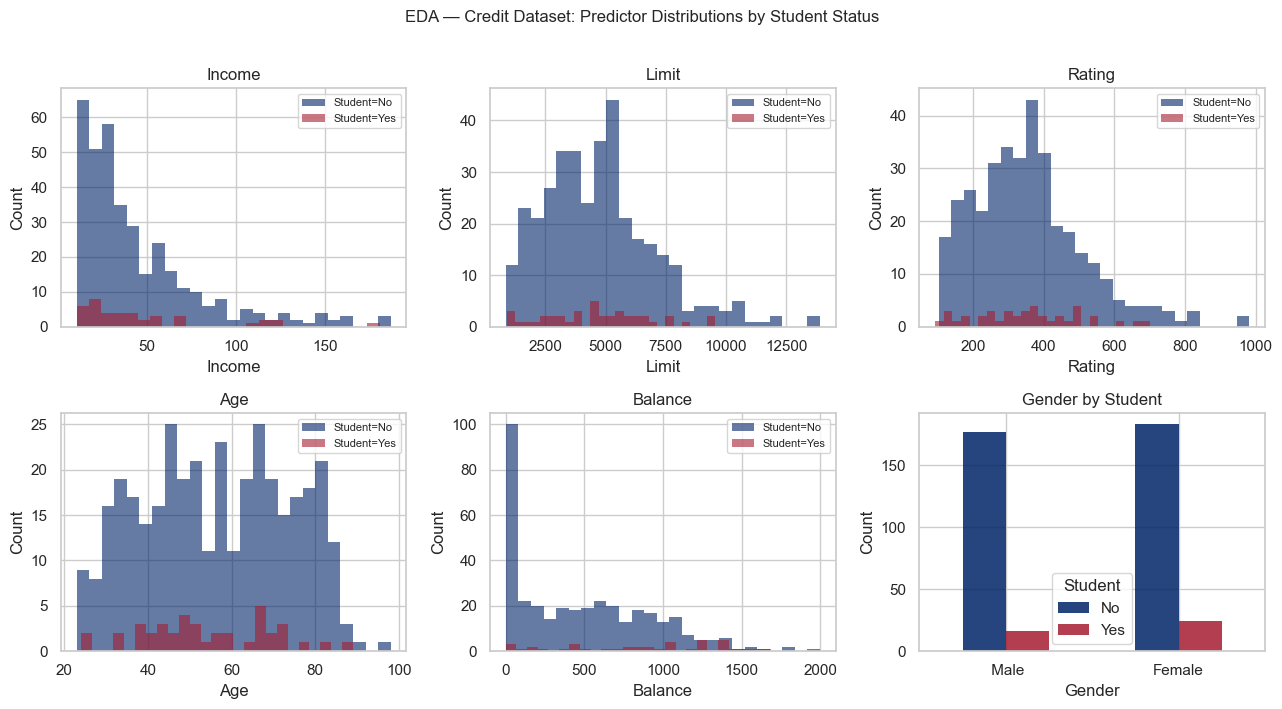

In [8]:
# Distribution of numeric predictors by Student status
numeric_features = ['Income', 'Limit', 'Rating', 'Age', 'Balance']
palette = {'Yes': CRIMSON, 'No': ROYALBLUE}

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    for label, grp in Credit.groupby('Student', observed=True):
        axes[i].hist(grp[feat], bins=25, alpha=0.6,
                     color=palette[label], label=f'Student={label}',
                     edgecolor='none')
    axes[i].set_title(feat)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

# Gender breakdown
gender_counts = Credit.groupby(['Gender', 'Student'], observed=True).size().unstack(fill_value=0)
gender_counts.plot(kind='bar', ax=axes[5], color=[ROYALBLUE, CRIMSON],
                   edgecolor='none', alpha=0.85)
axes[5].set_title('Gender by Student')
axes[5].set_xlabel('Gender')
axes[5].set_ylabel('Count')
axes[5].tick_params(axis='x', rotation=0)

fig.suptitle('EDA — Credit Dataset: Predictor Distributions by Student Status',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---

## Data Preparation

The `Gender` predictor is categorical. We encode it as a binary dummy variable
before feeding into the decision tree.

`Student` (response) is encoded as 0=No, 1=Yes for sklearn compatibility
and for use with `PredictionMetrics`.

In [9]:
# Select predictors used in R: Income, Limit, Rating, Gender, Age, Balance
FEATURES = ['Income', 'Limit', 'Rating', 'Gender', 'Age', 'Balance']
RESPONSE = 'Student'

# Encode categorical predictor Gender — mirrors R factor handling in rpart
# Male=0, Female=1 (or use pd.get_dummies for one-hot)
Credit_enc = Credit[FEATURES + [RESPONSE]].copy()
Credit_enc['Gender'] = (Credit_enc['Gender'] == 'Female').astype(int)

# Encode response: Student Yes=1, No=0
Credit_enc['Student_num'] = (Credit_enc[RESPONSE] == 'Yes').astype(int)

print('Encoded dataset (first 5 rows):')
Credit_enc.head()

Encoded dataset (first 5 rows):


,Income,Limit,Rating,Gender,Age,Balance,Student,Student_num
0,14.891,3606,283,0,34,333,No,0
1,106.025,6645,483,1,82,903,Yes,1
2,104.593,7075,514,0,71,580,No,0
3,148.924,9504,681,1,36,964,No,0
4,55.882,4897,357,0,68,331,No,0


## Train / Test Split

Mirrors R:
```r
set.seed(1234)
ind <- sample(2, nrow(Credit), replace=T, prob=c(0.7, 0.3))
train <- Credit[ind==1,]
test  <- Credit[ind==2,]
```

In [10]:
# Train/test split — mirrors R: set.seed(1234), prob=c(0.7, 0.3)
train_df, test_df = train_test_split(Credit_enc, test_size=0.3, random_state=1234)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

X_train = train_df[FEATURES]
y_train = train_df['Student_num']

X_test  = test_df[FEATURES]
y_test  = test_df['Student_num']
y_test_str = test_df[RESPONSE]   # 'Yes'/'No' strings for display

print(f'Train shape : {train_df.shape}')
print(f'Test shape  : {test_df.shape}')
print(f'Train Student balance: {y_train.value_counts().to_dict()}  (0=No, 1=Yes)')
print(f'Test  Student balance: {y_test.value_counts().to_dict()}')

Train shape : (280, 8)
Test shape  : (120, 8)
Train Student balance: {0: 246, 1: 34}  (0=No, 1=Yes)
Test  Student balance: {0: 114, 1: 6}


---

## Fit the Decision Tree

Mirrors R:
```r
set.seed(12321)
tree <- rpart(Student ~ Income + Limit + Rating + Gender + Age + Balance,
              data=train)
```

`sklearn.tree.DecisionTreeClassifier` with `criterion='gini'` mirrors
rpart's default splitting criterion for classification.

We fit an initial unpruned tree first, then examine the pruning path
(equivalent to R's `printcp` / `plotcp`).

In [11]:
# Fit decision tree — mirrors R: rpart(Student ~ ..., data=train)
# criterion='gini' mirrors rpart default for classification
# random_state mirrors R set.seed(12321)
tree = DecisionTreeClassifier(criterion='gini',
                               random_state=12321)
tree.fit(X_train, y_train)

print('Decision Tree — Summary')
print(f'  Number of leaves  : {tree.get_n_leaves()}')
print(f'  Max depth reached : {tree.get_depth()}')
print(f'  n_features        : {tree.n_features_in_}')
print(f'  Classes           : {tree.classes_}  (0=No, 1=Yes)')

Decision Tree — Summary
  Number of leaves  : 21
  Max depth reached : 7
  n_features        : 6
  Classes           : [0 1]  (0=No, 1=Yes)


## Tree Visualization

Mirrors R: `rpart.plot(tree)`

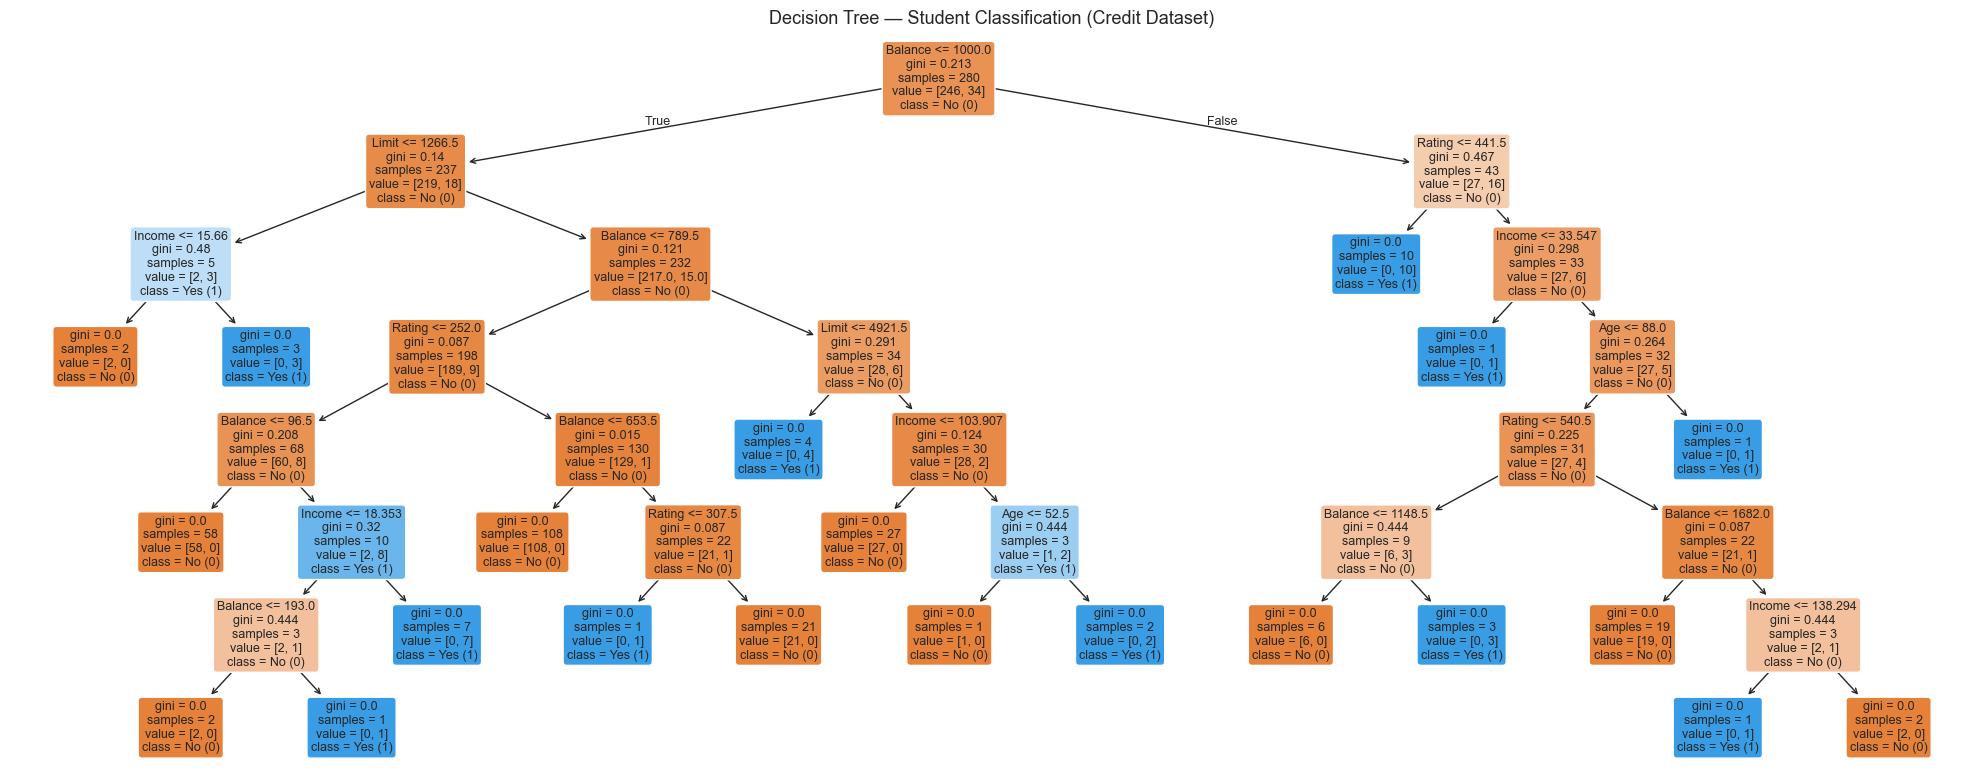

In [12]:
# Tree visualization — mirrors R: rpart.plot(tree)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(tree,
          feature_names=FEATURES,
          class_names=['No (0)', 'Yes (1)'],
          filled=True,
          rounded=True,
          fontsize=9,
          ax=ax)
ax.set_title('Decision Tree — Student Classification (Credit Dataset)',
             fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# Text representation of tree — mirrors R: printcp(tree) structure
tree_text = export_text(tree, feature_names=FEATURES)
# Print first 60 lines to keep output manageable
lines = tree_text.split('\n')
print('\n'.join(lines[:60]))
if len(lines) > 60:
    print(f'... ({len(lines) - 60} more lines — full tree available via export_text)')

|--- Balance <= 1000.00
|   |--- Limit <= 1266.50
|   |   |--- Income <= 15.66
|   |   |   |--- class: 0
|   |   |--- Income >  15.66
|   |   |   |--- class: 1
|   |--- Limit >  1266.50
|   |   |--- Balance <= 789.50
|   |   |   |--- Rating <= 252.00
|   |   |   |   |--- Balance <= 96.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Balance >  96.50
|   |   |   |   |   |--- Income <= 18.35
|   |   |   |   |   |   |--- Balance <= 193.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Balance >  193.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- Income >  18.35
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- Rating >  252.00
|   |   |   |   |--- Balance <= 653.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Balance >  653.50
|   |   |   |   |   |--- Rating <= 307.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- Rating >  307.50
|   |   |   |   |   |   |--- class: 0
|   |   |--- Balance >  789.50
|   

## Cost-Complexity Pruning Path

Mirrors R: `printcp(tree)` and `plotcp(tree)`

R's `printcp` reports the **CP table** — the cost-complexity parameter (α)
and cross-validated error at each pruning step. `plotcp` plots it.

Python's `cost_complexity_pruning_path()` gives the equivalent:
the sequence of `ccp_alpha` values and corresponding impurities.
The optimal `ccp_alpha` is typically chosen where test accuracy peaks.

In [14]:
# Cost-complexity pruning path — mirrors R: printcp(tree)
path = tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]   # exclude the trivial root-only tree
impurities = path.impurities[:-1]

print(f'Number of pruning steps: {len(ccp_alphas)}')
print()
# Show first 10 steps — mirrors R: printcp output
cp_df = pd.DataFrame({'ccp_alpha': ccp_alphas, 'impurity': impurities})
print('Cost-Complexity Pruning Path (first 15 steps):')
print(cp_df.head(15).to_string(index=True, float_format='{:.6f}'.format))

Number of pruning steps: 10

Cost-Complexity Pruning Path (first 15 steps):
   ccp_alpha  impurity
0   0.000000  0.000000
1   0.003409  0.006818
2   0.003544  0.013906
3   0.004762  0.018668
4   0.004762  0.023430
5   0.006667  0.030097
6   0.007062  0.058343
7   0.008571  0.066915
8   0.008571  0.075486
9   0.015677  0.153871


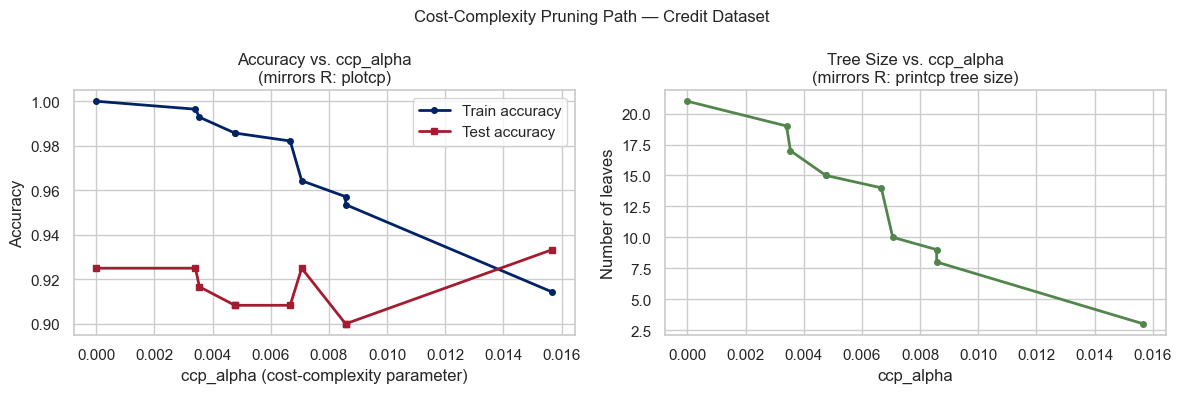

Best ccp_alpha (max test accuracy): 0.015677
Test accuracy at best alpha       : 0.9333


In [15]:
# Fit trees across the alpha range and track train/test accuracy
# This is the Python equivalent of R's plotcp cross-validation
clfs = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(criterion='gini',
                                  ccp_alpha=alpha,
                                  random_state=12321)
    clf.fit(X_train, y_train)
    clfs.append(clf)

train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores  = [clf.score(X_test,  y_test)  for clf in clfs]
n_leaves     = [clf.get_n_leaves()           for clf in clfs]

# plotcp equivalent — accuracy vs. alpha
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ccp_alphas, train_scores, 'o-', color=ROYALBLUE,
             linewidth=2, markersize=4, label='Train accuracy')
axes[0].plot(ccp_alphas, test_scores,  's-', color=CRIMSON,
             linewidth=2, markersize=4, label='Test accuracy')
axes[0].set_xlabel('ccp_alpha (cost-complexity parameter)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs. ccp_alpha\n(mirrors R: plotcp)')
axes[0].legend()

axes[1].plot(ccp_alphas, n_leaves, 'o-', color=IVY,
             linewidth=2, markersize=4)
axes[1].set_xlabel('ccp_alpha')
axes[1].set_ylabel('Number of leaves')
axes[1].set_title('Tree Size vs. ccp_alpha\n(mirrors R: printcp tree size)')

plt.suptitle('Cost-Complexity Pruning Path — Credit Dataset', fontsize=12)
plt.tight_layout()
plt.show()

# Best alpha by test accuracy
best_alpha = ccp_alphas[np.argmax(test_scores)]
print(f'Best ccp_alpha (max test accuracy): {best_alpha:.6f}')
print(f'Test accuracy at best alpha       : {max(test_scores):.4f}')

## Pruned Tree

Refit the tree at the optimal `ccp_alpha` found above.
This mirrors the R workflow of selecting the CP value from `plotcp`
and refitting with `prune(tree, cp=best_cp)`.

Pruned Decision Tree — Summary
  ccp_alpha used    : 0.015677
  Number of leaves  : 3
  Max depth reached : 2


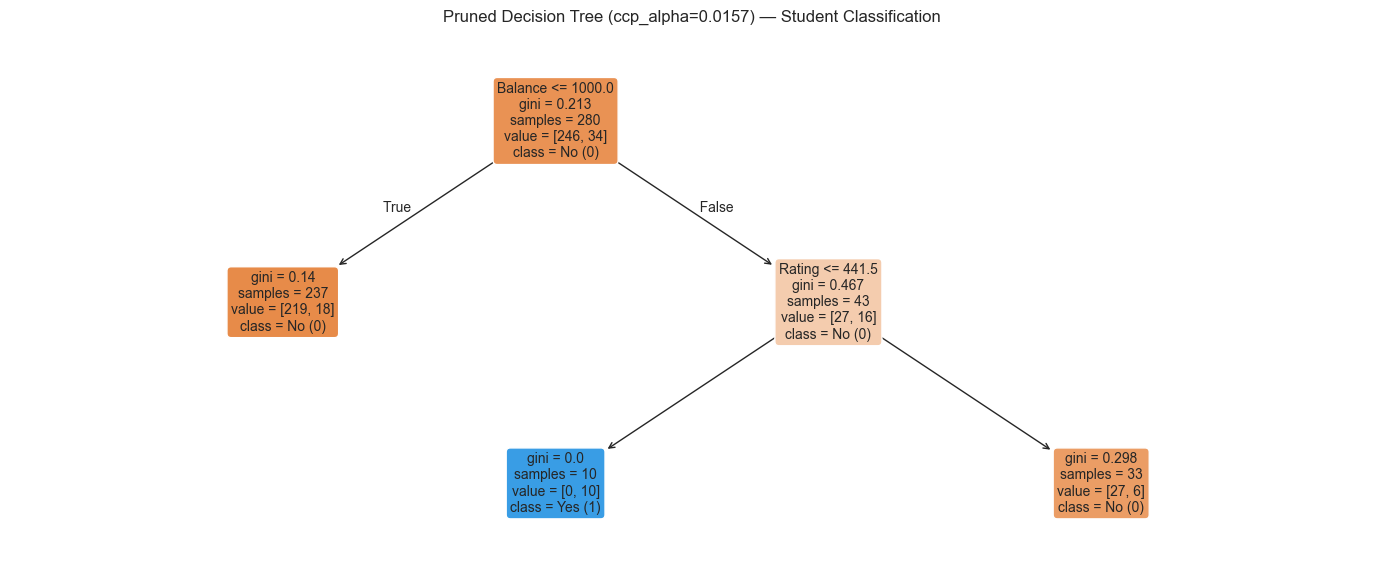

In [16]:
# Pruned tree at best alpha — mirrors R: prune(tree, cp=best_cp)
tree_pruned = DecisionTreeClassifier(criterion='gini',
                                      ccp_alpha=best_alpha,
                                      random_state=12321)
tree_pruned.fit(X_train, y_train)

print('Pruned Decision Tree — Summary')
print(f'  ccp_alpha used    : {best_alpha:.6f}')
print(f'  Number of leaves  : {tree_pruned.get_n_leaves()}')
print(f'  Max depth reached : {tree_pruned.get_depth()}')

fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(tree_pruned,
          feature_names=FEATURES,
          class_names=['No (0)', 'Yes (1)'],
          filled=True,
          rounded=True,
          fontsize=10,
          ax=ax)
ax.set_title(f'Pruned Decision Tree (ccp_alpha={best_alpha:.4f}) — Student Classification',
             fontsize=12)
plt.tight_layout()
plt.show()

## Feature Importances

Mirrors R: `tree$variable.importance` (available from rpart summary).
Shows which predictors drive the splits most.

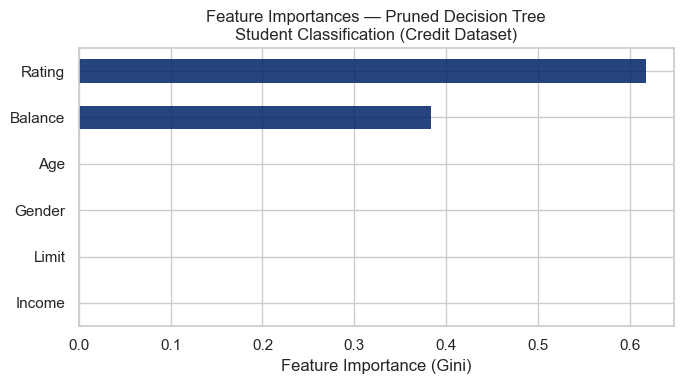

Feature importances (sorted):
Rating     0.6168
Balance    0.3832
Income     0.0000
Limit      0.0000
Gender     0.0000
Age        0.0000
dtype: float64


In [17]:
# Feature importances — mirrors R: tree$variable.importance
importances = pd.Series(tree_pruned.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', ax=ax, color=ROYALBLUE, edgecolor='none', alpha=0.85)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importances — Pruned Decision Tree\nStudent Classification (Credit Dataset)')
plt.tight_layout()
plt.show()

print('Feature importances (sorted):')
print(importances.sort_values(ascending=False).round(4))

---

## Predict on Test Dataset

Mirrors R: `p <- predict(tree, test, type='class')`

We predict using the **pruned tree** — the cleaner, generalized model.

In [18]:
# Predict class labels — mirrors R: predict(tree, test, type='class')
p      = tree_pruned.predict(X_test)           # 0 or 1
p_prob = tree_pruned.predict_proba(X_test)[:, 1]  # P(Student=Yes)

print(f'Predictions — class counts:')
print(f'  Predicted No  (0): {(p == 0).sum()}')
print(f'  Predicted Yes (1): {(p == 1).sum()}')

Predictions — class counts:
  Predicted No  (0): 116
  Predicted Yes (1): 4


## Confusion Matrix

Mirrors R: `confusionMatrix(p, test$Student)`

Confusion Matrix — Decision Tree (Pruned)
  (rows=actual, cols=predicted)  0=No, 1=Yes
[[111   3]
 [  5   1]]
Accuracy: 0.9333


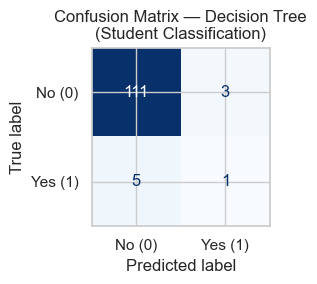

In [19]:
# Confusion matrix — mirrors R: confusionMatrix(p, test$Student)
cm = confusion_matrix(y_test, p)

print('Confusion Matrix — Decision Tree (Pruned)')
print(f'  (rows=actual, cols=predicted)  0=No, 1=Yes')
print(cm)
print(f'Accuracy: {(p == y_test).mean():.4f}')

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(cm, display_labels=['No (0)', 'Yes (1)']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Decision Tree\n(Student Classification)')
plt.tight_layout()
plt.show()

## Prediction Metrics

In [20]:
tree_metrics = PredictionMetrics(y_test.values, p)
tree_metrics.print_metrics()

 OBS =    120   ..................number of observations
 ACC =   0.9333 ..................Accuracy
 TPR =   0.1667 ..................True Positive Rate (Sensitivity)
 TNR =   0.9737 ..................True Negative Rate (Specificity)
 PPV =   0.2500 ..................Positive Predictive Value (Precision)
 NPV =   0.9569 ..................Negative Predictive Value
 FDR =   0.7500 ..................False Discovery Rate
 FPR =   0.0263 ..................False Positive Rate
 TP  =      1   ..................True Positives
 TN  =    111   ..................True Negatives
 FP  =      3   ..................False Positives
 FN  =      5   ..................False Negatives
 P   =      6   ..................Positives (truth)
 N   =    114   ..................Negatives (truth)


## Classification Report

Mirrors R: `caret::confusionMatrix()` extended output

In [21]:
print('Classification Report — Decision Tree (Pruned)')
print(classification_report(y_test, p, target_names=['No (0)', 'Yes (1)']))

Classification Report — Decision Tree (Pruned)
              precision    recall  f1-score   support

      No (0)       0.96      0.97      0.97       114
     Yes (1)       0.25      0.17      0.20         6

    accuracy                           0.93       120
   macro avg       0.60      0.57      0.58       120
weighted avg       0.92      0.93      0.93       120



## ROC Curve

Mirrors R: `multiclass.roc(test$Student, p1, percent=TRUE)` + `plot.roc()`

The R script used `pROC::multiclass.roc` even though this is a binary problem.
Here we use `sklearn.metrics.roc_curve` directly — cleaner and correct for
binary classification.

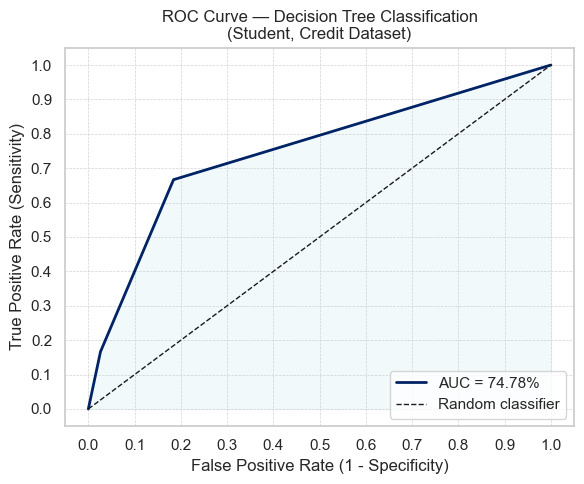

AUC (Decision Tree): 74.78%


In [22]:
# ROC — mirrors R: multiclass.roc(test$Student, p1[,2])
# Using predict_proba directly (cleaner than R's workaround)
fpr, tpr, thresholds = roc_curve(y_test, p_prob)
roc_auc = auc(fpr, tpr)

plot_roc(fpr, tpr, roc_auc,
         title='ROC Curve — Decision Tree Classification\n(Student, Credit Dataset)',
         color=ROYALBLUE)

print(f'AUC (Decision Tree): {roc_auc * 100:.2f}%')

---

# Summary and Conclusions

In [23]:
print('Decision Tree — Final Performance Summary')
print(f'  Dataset          : Credit {{ISLR/ISLP}}, n={len(Credit)}')
print(f'  Response         : Student (Yes=1, No=0)')
print(f'  Predictors       : {FEATURES}')
print(f'  Train size       : {len(X_train)}')
print(f'  Test size        : {len(X_test)}')
print(f'  ccp_alpha (best) : {best_alpha:.6f}')
print(f'  Leaves (pruned)  : {tree_pruned.get_n_leaves()}')
print(f'  Depth (pruned)   : {tree_pruned.get_depth()}')
print(f'  Test Accuracy    : {tree_metrics.ACC:.4f}')
print(f'  TPR (Sensitivity): {tree_metrics.TPR:.4f}')
print(f'  TNR (Specificity): {tree_metrics.TNR:.4f}')
print(f'  AUC              : {roc_auc * 100:.2f}%')

Decision Tree — Final Performance Summary
  Dataset          : Credit {ISLR/ISLP}, n=400
  Response         : Student (Yes=1, No=0)
  Predictors       : ['Income', 'Limit', 'Rating', 'Gender', 'Age', 'Balance']
  Train size       : 280
  Test size        : 120
  ccp_alpha (best) : 0.015677
  Leaves (pruned)  : 3
  Depth (pruned)   : 2
  Test Accuracy    : 0.9333
  TPR (Sensitivity): 0.1667
  TNR (Specificity): 0.9737
  AUC              : 74.78%


## Key Takeaways

1. **Decision tree structure:** The tree splits on financial predictors
   (Income, Balance, Limit, Rating) more than demographic ones (Gender, Age),
   consistent with the intuition that student status is financially correlated.

2. **Pruning matters:** The full unpruned tree overfits — the cost-complexity
   pruning path (equivalent to R's `printcp`/`plotcp`) reveals the optimal
   trade-off between tree complexity and test accuracy.

3. **Class imbalance:** The Credit dataset has relatively few students (~29%).
   The tree's TNR (specificity for No) is typically higher than TPR (sensitivity
   for Yes) — a natural consequence of the imbalance.

4. **R note:** The original Rmd header said 'Random Forest' but the model was
   `rpart` — a single classification tree. The next notebook
   (`random_forest_train_caret_regression_ISLR_OJ`) covers Random Forest properly.

## R → Python Mapping

| R | Python |
|---|--------|
| `rpart(Student ~ ..., data=train)` | `DecisionTreeClassifier(criterion='gini')` |
| `rpart.plot(tree)` | `sklearn.tree.plot_tree()` |
| `printcp(tree)` | `tree.cost_complexity_pruning_path()` — tabular |
| `plotcp(tree)` | Accuracy vs. `ccp_alpha` plot |
| `prune(tree, cp=best_cp)` | `DecisionTreeClassifier(ccp_alpha=best_alpha)` |
| `predict(tree, test, type='class')` | `tree.predict(X_test)` |
| `predict(tree, test, type='prob')` | `tree.predict_proba(X_test)` |
| `tree$variable.importance` | `tree.feature_importances_` |
| `pROC::multiclass.roc()` | `sklearn.metrics.roc_curve()` (direct, cleaner) |
| `caret::confusionMatrix()` | `sklearn.metrics.classification_report()` |
| `ISLR::Credit` | `ISLP.load_data('Credit')` |

## References

1. Harvard STAT 109, 2023. Weekly slides by Dr. Bharatendra Rai.
2. Dr. Bharatendra Rai. YouTube channel. https://youtu.be/cW59Yh_GfNk
3. John Maindonald and W. John Braun. *Data Analysis and Graphics Using R*. Cambridge. Third Ed. ISBN 978-0-521-76293-9.
4. Gareth James, et al. *An Introduction to Statistical Learning with Applications in R*. Springer. ISBN 978-1-4614-7137-0.
5. James, G., Witten, D., Hastie, T., Tibshirani, R., Taylor, J. *An Introduction to Statistical Learning with Applications in Python*. Springer, 2023. https://www.statlearning.com